# Consistent rollout biological retraining results

This notebook compares the previously successful consistent graph rollout model (`v2_sched_samp`) against the FTV-calibrated biological retraining grid. The deterministic comparison focuses on the hard setting: an autonomous rollout from baseline imaging (`T0`) to the post-treatment visit (`T3`) across the same 758-patient evaluation set.

The original question was whether the added endpoint objectives fixed the clinically important failure mode from the baseline model: the rollout geometry looked reasonable, but total functional tumor volume (FTV) was too low at T3. The completed follow-up question is whether the same conditional Monte Carlo sampler becomes better centered and sharper when it is run on the FTV-calibrated retrained models without changing the sampler.

These MC results evaluate the `runs/consistent_forecaster_v2_bio` retraining grid. That grid added aggregate FTV and alive-burden supervision while retaining the scheduled-sampling rollout setup. It was not the later random-start + horizon rerun. That distinction matters because this notebook isolates the effect of the biological endpoint objectives on deterministic calibration and conditional MC calibration.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

# Locate the repository root whether the notebook is run from the repo root or from notebooks/ispy2.
for candidate in [Path.cwd(), *Path.cwd().parents]:
    data_dir = candidate / "reports" / "consistent_forecaster_v2_bio_eval" / "notebook_exports"
    mc_root = candidate / "reports" / "conditional_mc_bio_retrained"
    if data_dir.exists() and mc_root.exists():
        REPO_ROOT = candidate
        DATA_DIR = data_dir
        MC_ROOT = mc_root
        break
else:
    raise FileNotFoundError(
        "Could not locate both reports/consistent_forecaster_v2_bio_eval/notebook_exports "
        "and reports/conditional_mc_bio_retrained"
    )

FIG_DIR = REPO_ROOT / "reports" / "figures" / "mc_bio_retraining"
FIG_DIR.mkdir(parents=True, exist_ok=True)

summary = pd.read_csv(DATA_DIR / "bio_vs_baseline_summary.csv")
paired = pd.read_csv(DATA_DIR / "bio_vs_baseline_paired_deltas.csv")
per_patient = pd.read_csv(DATA_DIR / "bio_vs_baseline_t3_per_patient.csv")

mc_summary = pd.read_csv(MC_ROOT / "mc_bio_comparison_summary.csv")
mc_gates = pd.read_csv(MC_ROOT / "mc_bio_decision_gates.csv")
mc_subgroups = pd.read_csv(MC_ROOT / "mc_bio_subgroup_summary.csv")

summary.shape, paired.shape, per_patient.shape, mc_summary.shape, mc_gates.shape, mc_subgroups.shape

((6, 31), (5, 13), (4548, 14), (24, 64), (24, 9), (312, 43))

## What changed in the retraining

The baseline model was already the strong version of the consistent rollout forecaster: it used scheduled sampling and learned to move the registered tumor graph forward through treatment. Its core supervision was local: node positions and node features.

The biological retraining grid added endpoint pressure on top of that local supervision:

- **Aggregate FTV loss** penalizes error in total predicted tumor burden after rollout, not only local node-feature error.
- **Alive supervision** asks the model to learn which graph nodes should still contribute to the tumor at later visits.
- **Scheduled-sampling rollout training was retained**, so the comparison asks whether biological endpoint losses improve the already successful rollout model.

A separate random-start + horizon rerun was trained later, but the MC results analyzed below are for the original FTV-calibrated bio grid. That makes the comparison clean: same conditional MC sampler, same cohort, same held-out fold protocol, and only the base model center changed.

FTV is significant because it is the model's clinically interpretable tumor-burden signal. A model can have acceptable-looking spatial displacement metrics while still predicting a tumor that is much too small or too large. For treatment-response modeling, that is not a minor bookkeeping error; it changes the estimated response trajectory and contaminates Monte Carlo response summaries.

In [2]:
cols = [
    "tag",
    "model_label",
    "n_patients_t3",
    "pred_ftv_ml_mean",
    "obs_ftv_ml_mean",
    "ftv_signed_err_ml_mean",
    "ftv_abs_err_ml_mean",
    "ftv_abs_err_ml_reduction_vs_baseline_pct",
    "swd_mm_mean",
    "chamfer_mm_mean",
    "dice_mean",
    "surface_dice_mean",
    "alive_count_abs_err_mean",
]
compact = summary[cols].copy()
compact = compact.sort_values("ftv_abs_err_ml_mean")
compact.style.format({
    "pred_ftv_ml_mean": "{:.2f}",
    "obs_ftv_ml_mean": "{:.2f}",
    "ftv_signed_err_ml_mean": "{:.2f}",
    "ftv_abs_err_ml_mean": "{:.2f}",
    "ftv_abs_err_ml_reduction_vs_baseline_pct": "{:.1f}%",
    "swd_mm_mean": "{:.4f}",
    "chamfer_mm_mean": "{:.4f}",
    "dice_mean": "{:.4f}",
    "surface_dice_mean": "{:.4f}",
    "alive_count_abs_err_mean": "{:.2f}",
})

,tag,model_label,n_patients_t3,pred_ftv_ml_mean,obs_ftv_ml_mean,ftv_signed_err_ml_mean,ftv_abs_err_ml_mean,ftv_abs_err_ml_reduction_vs_baseline_pct,swd_mm_mean,chamfer_mm_mean,dice_mean,surface_dice_mean,alive_count_abs_err_mean
4,bio_ftv020_alive005,High FTV + high alive,758,23.21,24.94,-1.73,5.88,54.3%,1.2940,2.8429,0.1331,0.4622,1.70
3,bio_ftv010_alive002,Medium FTV + medium alive,758,23.44,24.94,-1.50,5.99,53.5%,1.2938,2.8425,0.1331,0.4627,1.70
5,bio_ftv010_alive000,FTV-only ablation,758,23.44,24.94,-1.51,5.99,53.5%,1.2944,2.8436,0.1334,0.4629,1.70
2,bio_ftv005_alive001,Low FTV + low alive,758,23.85,24.94,-1.10,6.15,52.2%,1.2937,2.8423,0.1331,0.4627,1.70
1,bio_ftv000_alive002,Alive-only biological retraining,758,24.40,24.94,-0.54,6.39,50.4%,1.2933,2.8410,0.1338,0.4631,1.70
0,v2_sched_samp_baseline,Previous successful scheduled-sampling baseline,758,12.43,24.94,-12.51,12.88,0.0%,1.2910,2.8372,0.1338,0.4631,58.00


## Main result

The baseline scheduled-sampling model underpredicted mean T3 FTV by about **12.5 mL**: mean predicted FTV was **12.43 mL** against an observed mean of **24.94 mL**. Its T0-to-T3 FTV MAE was **12.88 mL**.

Every biological retraining candidate corrected most of that volume drift. The best FTV-MAE variant, `bio_ftv020_alive005`, reduced T0-to-T3 FTV MAE to **5.88 mL**, a **54.3% reduction** relative to the baseline. The mean paired patient-level MAE improvement was **7.00 mL** with an approximate 95% interval of **6.06 to 7.93 mL**, and **79.6%** of patients improved.

This is the key significance: the added biological losses did not merely tune a metric; they fixed the dominant endpoint-level failure mode of the rollout model. The model now lands near the correct cohort-level T3 tumor burden while retaining essentially the same spatial accuracy.

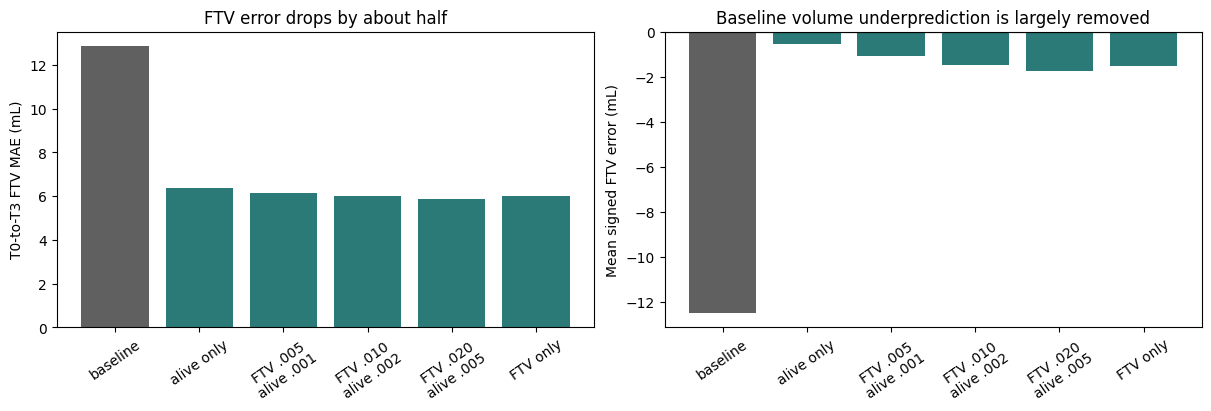

In [3]:
plot_df = summary.copy()
plot_df["short_label"] = plot_df["tag"].replace({
    "v2_sched_samp_baseline": "baseline",
    "bio_ftv000_alive002": "alive only",
    "bio_ftv005_alive001": "FTV .005\nalive .001",
    "bio_ftv010_alive002": "FTV .010\nalive .002",
    "bio_ftv020_alive005": "FTV .020\nalive .005",
    "bio_ftv010_alive000": "FTV only",
})
plot_df = plot_df.set_index("tag").loc[
    [
        "v2_sched_samp_baseline",
        "bio_ftv000_alive002",
        "bio_ftv005_alive001",
        "bio_ftv010_alive002",
        "bio_ftv020_alive005",
        "bio_ftv010_alive000",
    ]
].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
colors = ["#606060"] + ["#2b7a78"] * 5

axes[0].bar(plot_df["short_label"], plot_df["ftv_abs_err_ml_mean"], color=colors)
axes[0].set_ylabel("T0-to-T3 FTV MAE (mL)")
axes[0].set_title("FTV error drops by about half")
axes[0].tick_params(axis="x", rotation=35)

axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].bar(plot_df["short_label"], plot_df["ftv_signed_err_ml_mean"], color=colors)
axes[1].set_ylabel("Mean signed FTV error (mL)")
axes[1].set_title("Baseline volume underprediction is largely removed")
axes[1].tick_params(axis="x", rotation=35)

plt.show()

## Geometry did not collapse

The improvement is not explained by sacrificing point-cloud geometry. The changes in SWD, Chamfer distance, Dice, and surface Dice are very small relative to the absolute metric values. The best FTV model increases mean SWD by only about **0.003 mm** and Chamfer by about **0.006 mm**, while Dice changes by less than **0.001**.

That matters because the retraining objective was intended to make the rollout more biologically calibrated, not to replace the geometric graph model with a crude volume predictor. These results suggest the FTV objective acts as an aggregate calibration constraint on top of the existing geometric dynamics.

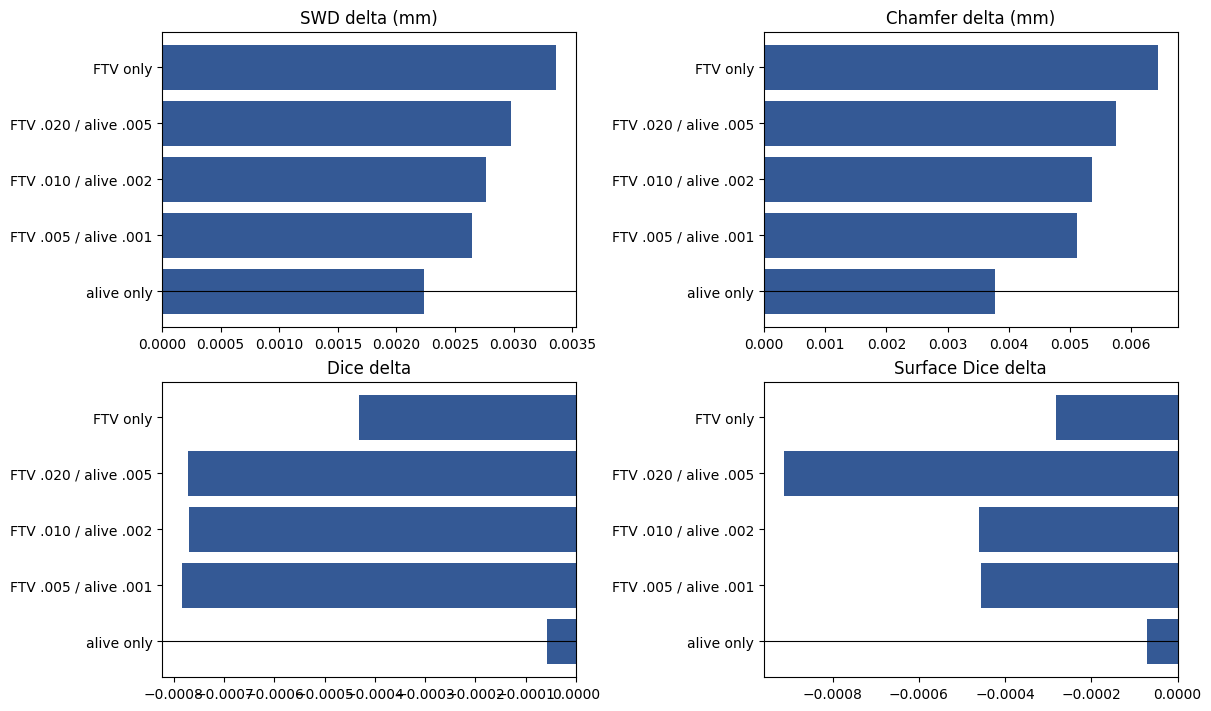

In [4]:
geo_cols = [
    ("swd_mm_delta_vs_baseline", "SWD delta (mm)"),
    ("chamfer_mm_delta_vs_baseline", "Chamfer delta (mm)"),
    ("dice_delta_vs_baseline", "Dice delta"),
    ("surface_dice_delta_vs_baseline", "Surface Dice delta"),
]
geo = summary[summary["tag"] != "v2_sched_samp_baseline"].copy()
geo["short_label"] = geo["tag"].replace({
    "bio_ftv000_alive002": "alive only",
    "bio_ftv005_alive001": "FTV .005 / alive .001",
    "bio_ftv010_alive002": "FTV .010 / alive .002",
    "bio_ftv020_alive005": "FTV .020 / alive .005",
    "bio_ftv010_alive000": "FTV only",
})

fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
for ax, (col, label) in zip(axes.ravel(), geo_cols):
    ax.axhline(0, color="black", linewidth=0.8)
    ax.barh(geo["short_label"], geo[col], color="#345995")
    ax.set_title(label)
plt.show()

## Paired patient-level comparison

The paired comparison below asks the stricter question: for the same patient, did the retrained model reduce T0-to-T3 FTV absolute error relative to the baseline? The answer is yes for roughly three quarters to four fifths of patients, depending on the retraining weights.

In [5]:
paired_view = paired[[
    "tag",
    "model_label",
    "n",
    "ftv_mae_delta_ml_mean",
    "ftv_mae_delta_ml_ci95_low",
    "ftv_mae_delta_ml_ci95_high",
    "ftv_mae_improved_patient_fraction",
    "swd_delta_mm_mean",
    "chamfer_delta_mm_mean",
    "dice_delta_mean",
]].sort_values("ftv_mae_delta_ml_mean", ascending=False)
paired_view.style.format({
    "ftv_mae_delta_ml_mean": "{:.2f}",
    "ftv_mae_delta_ml_ci95_low": "{:.2f}",
    "ftv_mae_delta_ml_ci95_high": "{:.2f}",
    "ftv_mae_improved_patient_fraction": "{:.1%}",
    "swd_delta_mm_mean": "{:.4f}",
    "chamfer_delta_mm_mean": "{:.4f}",
    "dice_delta_mean": "{:.4f}",
})

,tag,model_label,n,ftv_mae_delta_ml_mean,ftv_mae_delta_ml_ci95_low,ftv_mae_delta_ml_ci95_high,ftv_mae_improved_patient_fraction,swd_delta_mm_mean,chamfer_delta_mm_mean,dice_delta_mean
3,bio_ftv020_alive005,High FTV + high alive,758,7.00,6.06,7.93,79.6%,0.0030,0.0058,-0.0008
2,bio_ftv010_alive002,Medium FTV + medium alive,758,6.89,5.95,7.83,78.6%,0.0028,0.0054,-0.0008
4,bio_ftv010_alive000,FTV-only ablation,758,6.88,5.95,7.82,78.5%,0.0034,0.0064,-0.0004
1,bio_ftv005_alive001,Low FTV + low alive,758,6.73,5.78,7.68,77.4%,0.0026,0.0051,-0.0008
0,bio_ftv000_alive002,Alive-only biological retraining,758,6.49,5.52,7.46,74.0%,0.0022,0.0038,-0.0001


## Interpreting the alive objective

The alive-count error improves dramatically compared with the baseline: from about **58.0** nodes to about **1.7** nodes. However, that improvement is identical across the biological retraining variants, including the FTV-only ablation. I would not claim from this grid alone that the explicit alive loss is the driver of the alive-count improvement.

The cleaner interpretation is that the retrained rollout path and endpoint-aware supervision make the predicted tumor mass much better calibrated. The alive-loss term may still be useful, but this table does not isolate its contribution. The FTV-only ablation performs nearly as well as the medium FTV + alive model on FTV MAE, so the next decision should be based on validation priorities rather than assuming the alive term is proven.

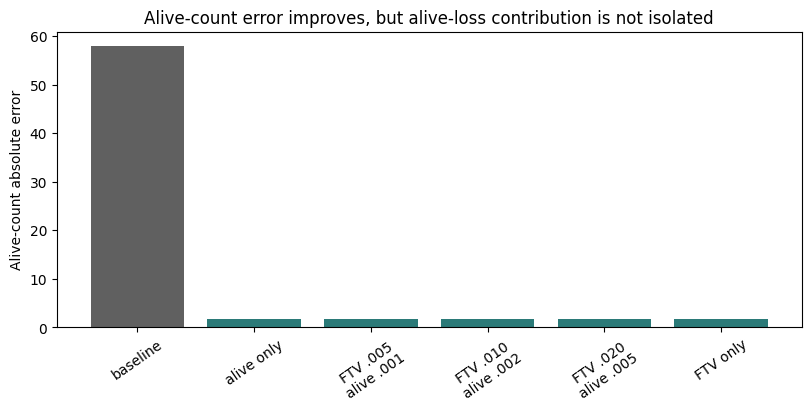

In [6]:
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
alive_df = plot_df.copy()
ax.bar(alive_df["short_label"], alive_df["alive_count_abs_err_mean"], color=colors)
ax.set_ylabel("Alive-count absolute error")
ax.set_title("Alive-count error improves, but alive-loss contribution is not isolated")
ax.tick_params(axis="x", rotation=35)
plt.show()

## Deterministic conclusion before the MC rerun

The deterministic retraining results made `bio_ftv020_alive005` the primary FTV-calibrated candidate because it had the lowest T0-to-T3 FTV MAE. The `bio_ftv010_alive000` FTV-only ablation and `bio_ftv010_alive002` medium FTV + alive model were kept as controls because their FTV performance was close and they test whether explicit alive supervision adds value beyond aggregate FTV calibration.

The scientific significance at this stage was that the consistent graph rollout model was no longer only a spatially plausible forecaster. With FTV-aware retraining, the predicted post-treatment tumor burden was much closer to the observed cohort burden without meaningful degradation in geometry. That made the retrained models worth carrying into conditional Monte Carlo uncertainty estimation.

## Updated conditional Monte Carlo results

The completed MC rerun used the same sampler, same held-out fold protocol, same 758-patient cohort, and the same 256 samples per rollout record. The only intended change was the deterministic model used as the center of the uncertainty distribution.

The result is much stronger than the original MC diagnostic. For `T0->T3`, the previous scheduled-sampling baseline had deterministic FTV bias of **-12.51 mL**, MC-mean FTV MAE of **15.26 mL**, raw 90% FTV coverage of **0.766**, conformal interval width of **59.51 mL**, CRPS of **8.35**, and MC alive-count error of **40.78** supervoxels.

The primary retrained candidate, `bio_ftv020_alive005`, changed that same `T0->T3` bucket to deterministic FTV bias **-1.73 mL**, MC-mean FTV MAE **7.61 mL**, raw 90% coverage **0.876**, conformal width **27.95 mL**, CRPS **5.16**, and alive-count error **2.69**. In relative terms, this is a **50.1% reduction** in MC-mean FTV MAE, a **53.0% reduction** in conformal interval width, a **38.3% reduction** in Continuous Ranked Probability Score, and a **93.4% reduction** in MC alive-count error.

All three retrained candidates passed all prespecified T0-to-T3 decision gates. The FTV-only ablation had the lowest T0-to-T3 MC-mean FTV MAE and narrowest conformal width, but its MC alive-count error was higher than the FTV+alive variants. That keeps `bio_ftv020_alive005` as the best balanced primary candidate rather than making the FTV-only ablation the default final model.

In [7]:
model_order = [
    "v2_sched_samp_baseline",
    "bio_ftv020_alive005",
    "bio_ftv010_alive000",
    "bio_ftv010_alive002",
]
model_labels = {
    "v2_sched_samp_baseline": "baseline",
    "bio_ftv020_alive005": "FTV .020\nalive .005",
    "bio_ftv010_alive000": "FTV only",
    "bio_ftv010_alive002": "FTV .010\nalive .002",
}
colors = {
    "v2_sched_samp_baseline": "#686868",
    "bio_ftv020_alive005": "#0f766e",
    "bio_ftv010_alive000": "#2b6cb0",
    "bio_ftv010_alive002": "#7c3aed",
}

t0t3 = mc_summary[mc_summary["bucket"].eq("T0->T3")].set_index("model_tag").loc[model_order].reset_index()
mc_t3_view = t0t3[[
    "model_tag",
    "det_ftv_bias_ml_mean",
    "det_ftv_mae_ml_mean",
    "mc_mean_ftv_bias_ml_mean",
    "mc_mean_ftv_mae_ml_mean",
    "coverage90_ftv_raw_mean",
    "coverage90_ftv_conformal_mean",
    "ftv_raw_width90_ml_mean",
    "ftv_conformal_width90_ml_mean",
    "crps_ftv_mean",
    "alive_count_abs_err_mc_mean_mean",
    "swd_mm_mc_mean_mean",
    "chamfer_mm_mc_mean_mean",
    "dice_mc_mean_mean",
    "high_t3_mc_mean_ftv_mae_ml_mean",
]].copy()
mc_t3_view.insert(1, "short_label", mc_t3_view["model_tag"].map(model_labels))

mc_t3_view.style.format({
    "det_ftv_bias_ml_mean": "{:.2f}",
    "det_ftv_mae_ml_mean": "{:.2f}",
    "mc_mean_ftv_bias_ml_mean": "{:.2f}",
    "mc_mean_ftv_mae_ml_mean": "{:.2f}",
    "coverage90_ftv_raw_mean": "{:.3f}",
    "coverage90_ftv_conformal_mean": "{:.3f}",
    "ftv_raw_width90_ml_mean": "{:.2f}",
    "ftv_conformal_width90_ml_mean": "{:.2f}",
    "crps_ftv_mean": "{:.2f}",
    "alive_count_abs_err_mc_mean_mean": "{:.2f}",
    "swd_mm_mc_mean_mean": "{:.3f}",
    "chamfer_mm_mc_mean_mean": "{:.3f}",
    "dice_mc_mean_mean": "{:.3f}",
    "high_t3_mc_mean_ftv_mae_ml_mean": "{:.2f}",
})

,model_tag,short_label,det_ftv_bias_ml_mean,det_ftv_mae_ml_mean,mc_mean_ftv_bias_ml_mean,mc_mean_ftv_mae_ml_mean,coverage90_ftv_raw_mean,coverage90_ftv_conformal_mean,ftv_raw_width90_ml_mean,ftv_conformal_width90_ml_mean,crps_ftv_mean,alive_count_abs_err_mc_mean_mean,swd_mm_mc_mean_mean,chamfer_mm_mc_mean_mean,dice_mc_mean_mean,high_t3_mc_mean_ftv_mae_ml_mean
0,v2_sched_samp_baseline,baseline,-12.51,12.88,6.36,15.26,0.766,0.901,56.87,59.51,8.35,40.78,1.320,3.656,0.047,42.59
1,bio_ftv020_alive005,FTV .020 alive .005,-1.73,5.88,1.93,7.61,0.876,0.901,24.42,27.95,5.16,2.69,1.207,3.485,0.051,29.65
2,bio_ftv010_alive000,FTV only,-1.51,5.99,1.14,7.31,0.875,0.901,23.96,26.92,5.15,7.00,1.214,3.498,0.051,30.85
3,bio_ftv010_alive002,FTV .010 alive .002,-1.50,5.99,1.76,7.53,0.883,0.901,24.81,29.14,5.19,2.70,1.205,3.485,0.051,29.79


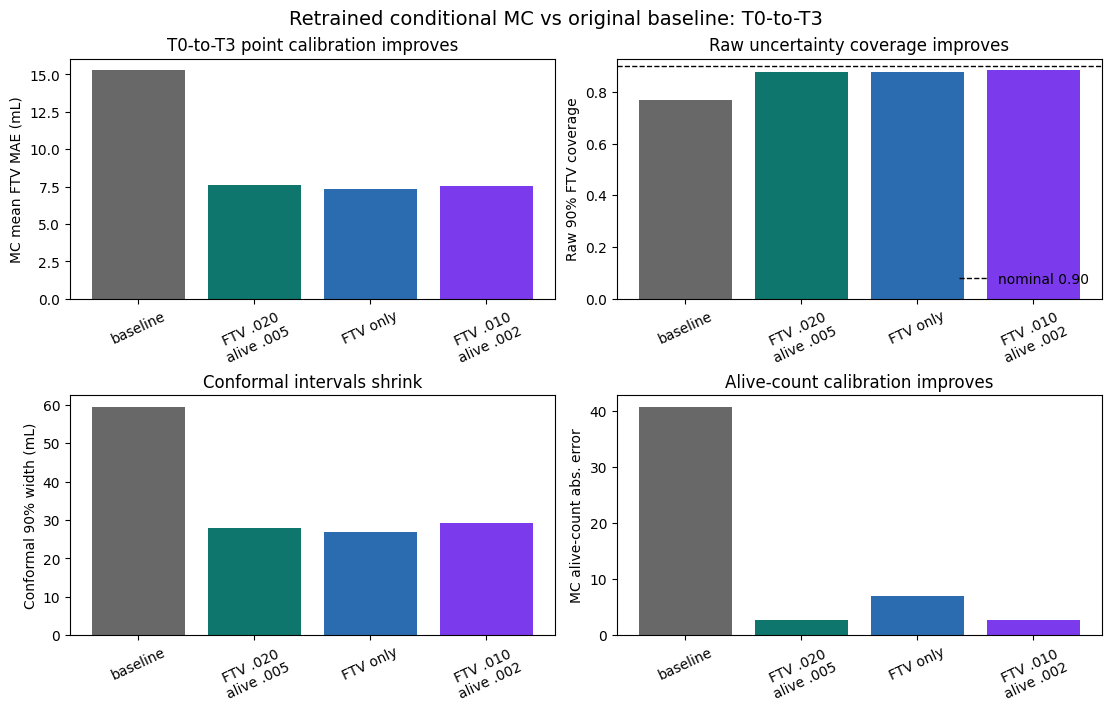

In [8]:
plot_metrics = [
    ("mc_mean_ftv_mae_ml_mean", "MC mean FTV MAE (mL)", False),
    ("coverage90_ftv_raw_mean", "Raw 90% FTV coverage", True),
    ("ftv_conformal_width90_ml_mean", "Conformal 90% width (mL)", False),
    ("alive_count_abs_err_mc_mean_mean", "MC alive-count abs. error", False),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
labels = [model_labels[m] for m in t0t3["model_tag"]]
bar_colors = [colors[m] for m in t0t3["model_tag"]]
for ax, (metric, ylabel, show_target) in zip(axes.ravel(), plot_metrics):
    ax.bar(labels, t0t3[metric], color=bar_colors)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=25)
    if show_target:
        ax.axhline(0.90, color="black", linestyle="--", linewidth=1, label="nominal 0.90")
        ax.legend(frameon=False, loc="lower right")
    if metric == "mc_mean_ftv_mae_ml_mean":
        ax.set_title("T0-to-T3 point calibration improves")
    elif metric == "coverage90_ftv_raw_mean":
        ax.set_title("Raw uncertainty coverage improves")
    elif metric == "ftv_conformal_width90_ml_mean":
        ax.set_title("Conformal intervals shrink")
    else:
        ax.set_title("Alive-count calibration improves")

fig.suptitle("Retrained conditional MC vs original baseline: T0-to-T3", fontsize=14)
fig.savefig(FIG_DIR / "mc_bio_retrained_t0t3_summary.png", dpi=220, bbox_inches="tight")
plt.show()

## T3 conditioning buckets

The improvement is not limited to one conditioning setup. Across `T0->T3`, `T1->T3`, and `T2->T3`, the retrained MC distributions have lower MC-mean FTV MAE, lower CRPS, and much smaller conformal intervals than the baseline. The later `T2->T3` setting is still the easiest volume prediction problem, but the key point is that the base-model correction improves all T3 uncertainty summaries while preserving spatial metrics.

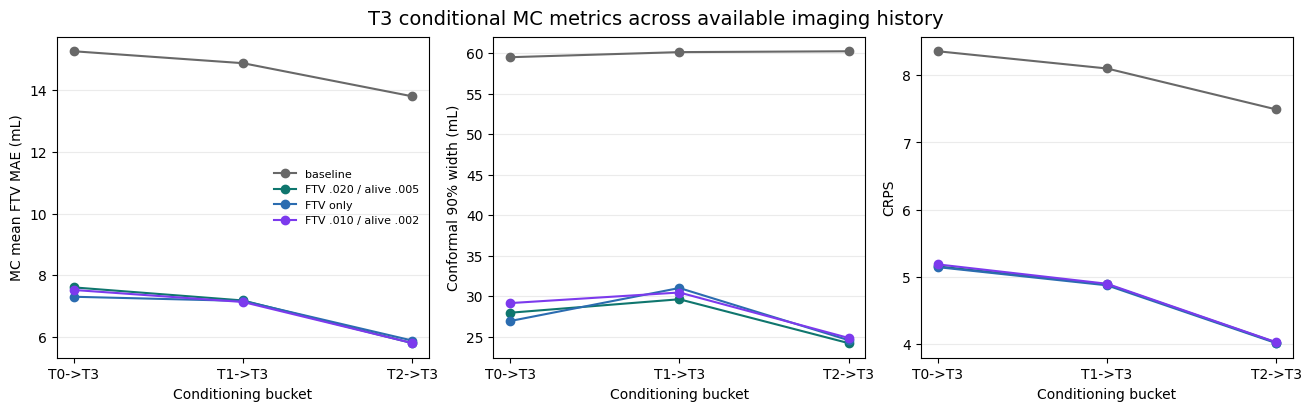

In [9]:
t3_buckets = ["T0->T3", "T1->T3", "T2->T3"]
t3_compare = mc_summary[
    mc_summary["bucket"].isin(t3_buckets) & mc_summary["model_tag"].isin(model_order)
].copy()
t3_compare["model_tag"] = pd.Categorical(t3_compare["model_tag"], categories=model_order, ordered=True)
t3_compare["bucket"] = pd.Categorical(t3_compare["bucket"], categories=t3_buckets, ordered=True)
t3_compare = t3_compare.sort_values(["model_tag", "bucket"])

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
for model_tag in model_order:
    d = t3_compare[t3_compare["model_tag"].eq(model_tag)]
    label = model_labels[model_tag].replace("\n", " / ")
    axes[0].plot(d["bucket"], d["mc_mean_ftv_mae_ml_mean"], marker="o", label=label, color=colors[model_tag])
    axes[1].plot(d["bucket"], d["ftv_conformal_width90_ml_mean"], marker="o", label=label, color=colors[model_tag])
    axes[2].plot(d["bucket"], d["crps_ftv_mean"], marker="o", label=label, color=colors[model_tag])

axes[0].set_ylabel("MC mean FTV MAE (mL)")
axes[1].set_ylabel("Conformal 90% width (mL)")
axes[2].set_ylabel("CRPS")
for ax in axes:
    ax.set_xlabel("Conditioning bucket")
    ax.grid(axis="y", alpha=0.25)
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("T3 conditional MC metrics across available imaging history", fontsize=14)
fig.savefig(FIG_DIR / "mc_bio_retrained_t3_buckets.png", dpi=220, bbox_inches="tight")
plt.show()

## Decision gates and subgroup drift

The decision-gate table is clean: every retrained candidate passes all eight T0-to-T3 gates. The main remaining nuance is subgroup drift. For the primary model, the HR-/HER2+ subgroup is the hardest T0-to-T3 subgroup: it has the largest deterministic FTV MAE, the largest MC-mean FTV MAE, the lowest raw coverage, and the worst CRPS. The pCR label is useful here only as a stratification variable for retrospective error analysis; the MC near-zero T3 MRI FTV diagnostic is not a pCR probability and was not trained as one.

In [10]:
gate_counts = mc_gates.groupby("model_tag")["pass"].agg(["sum", "count"]).loc[
    ["bio_ftv020_alive005", "bio_ftv010_alive000", "bio_ftv010_alive002"]
]
gate_counts["all_passed"] = gate_counts["sum"].eq(gate_counts["count"])

gate_counts

,sum,count,all_passed
model_tag,,,
bio_ftv020_alive005,8,8,True
bio_ftv010_alive000,8,8,True
bio_ftv010_alive002,8,8,True


In [11]:
primary_t0t3_subgroups = mc_subgroups[
    mc_subgroups["model_tag"].eq("bio_ftv020_alive005") & mc_subgroups["bucket"].eq("T0->T3")
].copy()

subgroup_view = primary_t0t3_subgroups[[
    "subgroup_type",
    "subgroup_value",
    "n_patients",
    "det_ftv_bias_ml_mean",
    "det_ftv_mae_ml_mean",
    "mc_mean_ftv_bias_ml_mean",
    "mc_mean_ftv_mae_ml_mean",
    "coverage90_ftv_raw_mean",
    "ftv_conformal_width90_ml_mean",
    "crps_ftv_mean",
    "near_zero_ftv_prob_mean",
    "alive_count_abs_err_mc_mean_mean",
]].sort_values(["subgroup_type", "subgroup_value"])

subgroup_view.style.format({
    "det_ftv_bias_ml_mean": "{:.2f}",
    "det_ftv_mae_ml_mean": "{:.2f}",
    "mc_mean_ftv_bias_ml_mean": "{:.2f}",
    "mc_mean_ftv_mae_ml_mean": "{:.2f}",
    "coverage90_ftv_raw_mean": "{:.3f}",
    "ftv_conformal_width90_ml_mean": "{:.2f}",
    "crps_ftv_mean": "{:.2f}",
    "near_zero_ftv_prob_mean": "{:.3f}",
    "alive_count_abs_err_mc_mean_mean": "{:.2f}",
})

,subgroup_type,subgroup_value,n_patients,det_ftv_bias_ml_mean,det_ftv_mae_ml_mean,mc_mean_ftv_bias_ml_mean,mc_mean_ftv_mae_ml_mean,coverage90_ftv_raw_mean,ftv_conformal_width90_ml_mean,crps_ftv_mean,near_zero_ftv_prob_mean,alive_count_abs_err_mc_mean_mean
172,collection,ACRIN-6698,202,0.26,3.71,3.90,5.74,0.901,26.97,3.30,0.066,2.21
173,collection,ISPY2,556,-2.46,6.67,1.22,8.29,0.867,28.31,5.83,0.055,2.87
262,fold,0,147,-1.36,5.54,2.30,7.40,0.850,27.85,4.97,0.051,1.84
263,fold,1,154,-3.68,7.36,0.15,8.62,0.877,28.72,6.27,0.050,1.01
264,fold,2,146,-2.96,6.70,0.66,8.25,0.877,27.12,5.79,0.064,1.27
265,fold,3,151,0.50,4.98,4.27,7.02,0.874,29.07,4.34,0.058,7.04
266,fold,4,160,-1.19,4.88,2.26,6.80,0.900,27.01,4.45,0.063,2.29
124,pCR,0,519,-2.18,6.68,1.64,8.41,0.863,28.55,5.85,0.051,2.49
125,pCR,1,239,-0.76,4.15,2.57,5.87,0.904,26.64,3.64,0.071,3.13
56,subtype,HR+/HER2+,128,1.22,3.74,4.88,6.10,0.906,28.20,3.43,0.074,7.24


## Patient-level uncertainty trajectory visuals

Yes: the MC outputs contain patient-level means and standard deviations for each future visit. The most direct visualization is a trajectory plot from T0 to T3 where T0 is the observed baseline FTV, the black line is the observed follow-up FTV, and each model gets an MC mean line with a shaded +/- 1 standard deviation band.

These plots are different from the aggregate tables. The tables say the retrained model is better on average; the trajectory plots show what that means patient by patient. A better calibrated model should have its mean trajectory closer to the observed trajectory and should not need extremely wide uncertainty bands to cover the true future FTV.

In [12]:
baseline_pp = pd.read_parquet(REPO_ROOT / "reports" / "conditional_mc_consistent_rollout" / "conditional_mc_per_patient.parquet")
primary_pp = pd.read_parquet(MC_ROOT / "bio_ftv020_alive005" / "conditional_mc_per_patient.parquet")

VISITS = ["T0", "T1", "T2", "T3"]
FUTURE_VISITS = ["T1", "T2", "T3"]

def t0_rows(df):
    rows = df[df["start_visit"].eq("T0")].copy()
    rows["predicted_visit"] = pd.Categorical(rows["predicted_visit"], categories=FUTURE_VISITS, ordered=True)
    return rows.sort_values(["patient_id", "predicted_visit"])

baseline_t0 = t0_rows(baseline_pp)
primary_t0 = t0_rows(primary_pp)

t3_base = baseline_t0[baseline_t0["predicted_visit"].eq("T3")].set_index("patient_id")
t3_primary = primary_t0[primary_t0["predicted_visit"].eq("T3")].set_index("patient_id")

patient_selector = t3_base[["obs_ftv_ml", "ftv_t0_ml", "subtype", "pCR", "collection", "ftv_mc_mean_ml", "ftv_mc_std_ml"]].join(
    t3_primary[["ftv_mc_mean_ml", "ftv_mc_std_ml"]],
    rsuffix="_primary",
)
patient_selector = patient_selector.rename(columns={
    "ftv_mc_mean_ml": "baseline_mc_mean_t3_ml",
    "ftv_mc_std_ml": "baseline_mc_std_t3_ml",
    "ftv_mc_mean_ml_primary": "primary_mc_mean_t3_ml",
    "ftv_mc_std_ml_primary": "primary_mc_std_t3_ml",
})
patient_selector["baseline_mc_abs_err_t3_ml"] = (patient_selector["baseline_mc_mean_t3_ml"] - patient_selector["obs_ftv_ml"]).abs()
patient_selector["primary_mc_abs_err_t3_ml"] = (patient_selector["primary_mc_mean_t3_ml"] - patient_selector["obs_ftv_ml"]).abs()
patient_selector["mc_abs_err_gain_t3_ml"] = patient_selector["baseline_mc_abs_err_t3_ml"] - patient_selector["primary_mc_abs_err_t3_ml"]

selected = []
selection_notes = []
for label, q in [("low observed T3", 0.10), ("median observed T3", 0.50), ("high observed T3", 0.90)]:
    target = patient_selector["obs_ftv_ml"].quantile(q)
    candidates = patient_selector.loc[~patient_selector.index.isin(selected)]
    pid = (candidates["obs_ftv_ml"] - target).abs().idxmin()
    selected.append(pid)
    selection_notes.append((label, pid))

candidates = patient_selector.loc[~patient_selector.index.isin(selected)]
pid = candidates["mc_abs_err_gain_t3_ml"].idxmax()
selected.append(pid)
selection_notes.append(("largest MC-mean error reduction", pid))

pd.DataFrame(selection_notes, columns=["selection_reason", "patient_id"]).join(
    patient_selector.loc[selected, [
        "collection", "subtype", "pCR", "ftv_t0_ml", "obs_ftv_ml",
        "baseline_mc_mean_t3_ml", "baseline_mc_std_t3_ml",
        "primary_mc_mean_t3_ml", "primary_mc_std_t3_ml", "mc_abs_err_gain_t3_ml",
    ]].reset_index(drop=True)
).style.format({
    "ftv_t0_ml": "{:.2f}",
    "obs_ftv_ml": "{:.2f}",
    "baseline_mc_mean_t3_ml": "{:.2f}",
    "baseline_mc_std_t3_ml": "{:.2f}",
    "primary_mc_mean_t3_ml": "{:.2f}",
    "primary_mc_std_t3_ml": "{:.2f}",
    "mc_abs_err_gain_t3_ml": "{:.2f}",
})

,selection_reason,patient_id,collection,subtype,pCR,ftv_t0_ml,obs_ftv_ml,baseline_mc_mean_t3_ml,baseline_mc_std_t3_ml,primary_mc_mean_t3_ml,primary_mc_std_t3_ml,mc_abs_err_gain_t3_ml
0,low observed T3,ISPY2-575372,ISPY2,TNBC,1,2.75,2.79,17.32,33.92,6.59,19.45,10.73
1,median observed T3,ACRIN-6698-899692,ACRIN-6698,TNBC,1,10.55,12.48,18.28,17.58,13.78,16.26,4.49
2,high observed T3,ISPY2-732137,ISPY2,TNBC,0,44.50,58.68,48.59,33.86,54.40,18.41,5.81
3,largest MC-mean error reduction,ISPY2-327133,ISPY2,TNBC,0,433.38,395.92,186.60,46.06,243.53,16.80,56.93


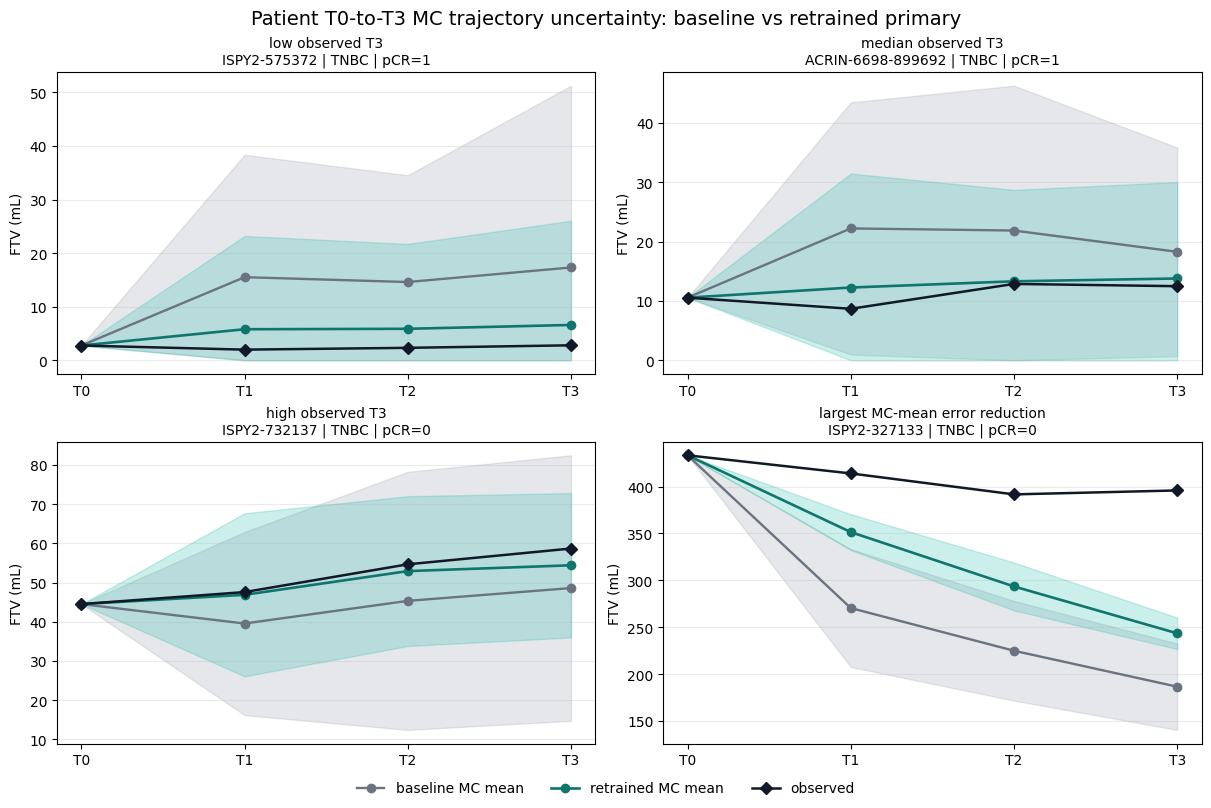

In [13]:
def patient_trajectory(rows, patient_id):
    p = rows[rows["patient_id"].eq(patient_id)].set_index("predicted_visit").loc[FUTURE_VISITS]
    ftv_t0 = float(p["ftv_t0_ml"].iloc[0])
    return {
        "obs": np.array([ftv_t0, *p["obs_ftv_ml"].to_numpy(dtype=float)]),
        "det": np.array([ftv_t0, *p["pred_ftv_det_ml"].to_numpy(dtype=float)]),
        "mean": np.array([ftv_t0, *p["ftv_mc_mean_ml"].to_numpy(dtype=float)]),
        "std": np.array([0.0, *p["ftv_mc_std_ml"].to_numpy(dtype=float)]),
    }

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
x = np.arange(len(VISITS))
for ax, patient_id, (reason, _) in zip(axes.ravel(), selected, selection_notes):
    b = patient_trajectory(baseline_t0, patient_id)
    u = patient_trajectory(primary_t0, patient_id)
    meta = patient_selector.loc[patient_id]

    ax.fill_between(x, np.maximum(0, b["mean"] - b["std"]), b["mean"] + b["std"], color="#9ca3af", alpha=0.25)
    ax.plot(x, b["mean"], color="#6b7280", marker="o", linewidth=1.7, label="baseline MC mean")
    ax.fill_between(x, np.maximum(0, u["mean"] - u["std"]), u["mean"] + u["std"], color="#14b8a6", alpha=0.22)
    ax.plot(x, u["mean"], color="#0f766e", marker="o", linewidth=1.9, label="retrained MC mean")
    ax.plot(x, b["obs"], color="#111827", marker="D", linewidth=1.8, label="observed")

    ax.set_xticks(x, VISITS)
    ax.set_ylabel("FTV (mL)")
    ax.grid(axis="y", alpha=0.25)
    ax.set_title(f"{reason}\n{patient_id} | {meta['subtype']} | pCR={int(meta['pCR'])}", fontsize=10)

handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=3, frameon=False)
fig.suptitle("Patient T0-to-T3 MC trajectory uncertainty: baseline vs retrained primary", fontsize=14)
fig.savefig(FIG_DIR / "mc_patient_trajectory_mean_std_examples.png", dpi=220, bbox_inches="tight")
plt.show()

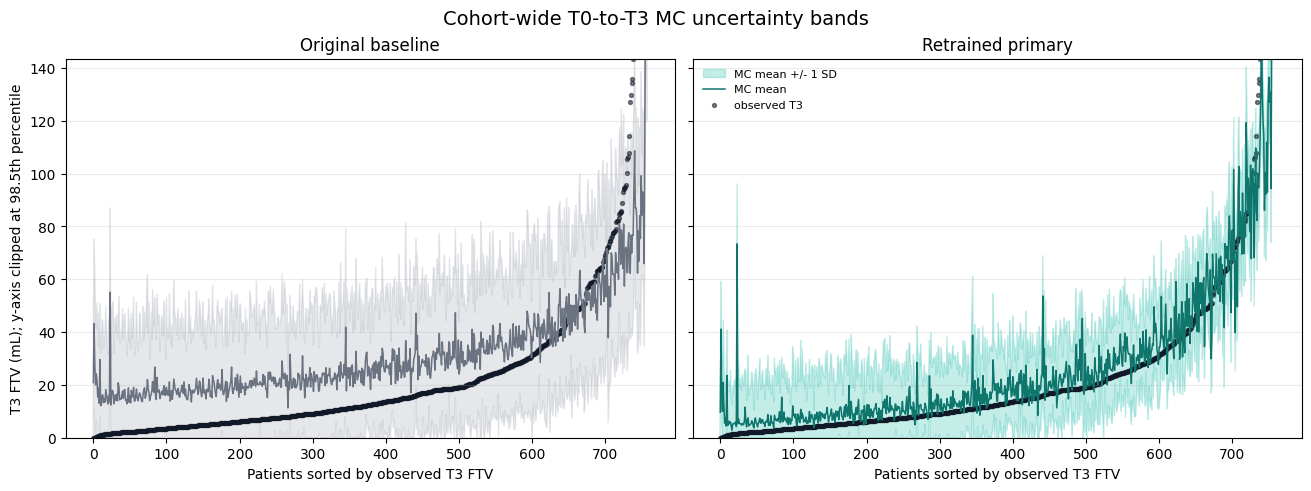

In [14]:
t3_uncertainty = patient_selector.sort_values("obs_ftv_ml").reset_index().rename(columns={"index": "patient_id"})
idx = np.arange(len(t3_uncertainty))
upper_limit = np.nanquantile(
    np.r_[
        t3_uncertainty["obs_ftv_ml"].to_numpy(),
        (t3_uncertainty["baseline_mc_mean_t3_ml"] + t3_uncertainty["baseline_mc_std_t3_ml"]).to_numpy(),
        (t3_uncertainty["primary_mc_mean_t3_ml"] + t3_uncertainty["primary_mc_std_t3_ml"]).to_numpy(),
    ],
    0.985,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True, constrained_layout=True)
for ax, mean_col, std_col, title, color, band_color in [
    (axes[0], "baseline_mc_mean_t3_ml", "baseline_mc_std_t3_ml", "Original baseline", "#6b7280", "#9ca3af"),
    (axes[1], "primary_mc_mean_t3_ml", "primary_mc_std_t3_ml", "Retrained primary", "#0f766e", "#14b8a6"),
]:
    mean = t3_uncertainty[mean_col].to_numpy(dtype=float)
    std = t3_uncertainty[std_col].to_numpy(dtype=float)
    ax.fill_between(idx, np.maximum(0, mean - std), mean + std, color=band_color, alpha=0.25, label="MC mean +/- 1 SD")
    ax.plot(idx, mean, color=color, linewidth=1.1, label="MC mean")
    ax.scatter(idx, t3_uncertainty["obs_ftv_ml"], s=8, color="#111827", alpha=0.55, label="observed T3")
    ax.set_title(title)
    ax.set_xlabel("Patients sorted by observed T3 FTV")
    ax.set_ylim(0, upper_limit)
    ax.grid(axis="y", alpha=0.25)
axes[0].set_ylabel("T3 FTV (mL); y-axis clipped at 98.5th percentile")
axes[1].legend(frameon=False, loc="upper left", fontsize=8)
fig.suptitle("Cohort-wide T0-to-T3 MC uncertainty bands", fontsize=14)
fig.savefig(FIG_DIR / "mc_t0t3_patient_uncertainty_sorted.png", dpi=220, bbox_inches="tight")
plt.show()

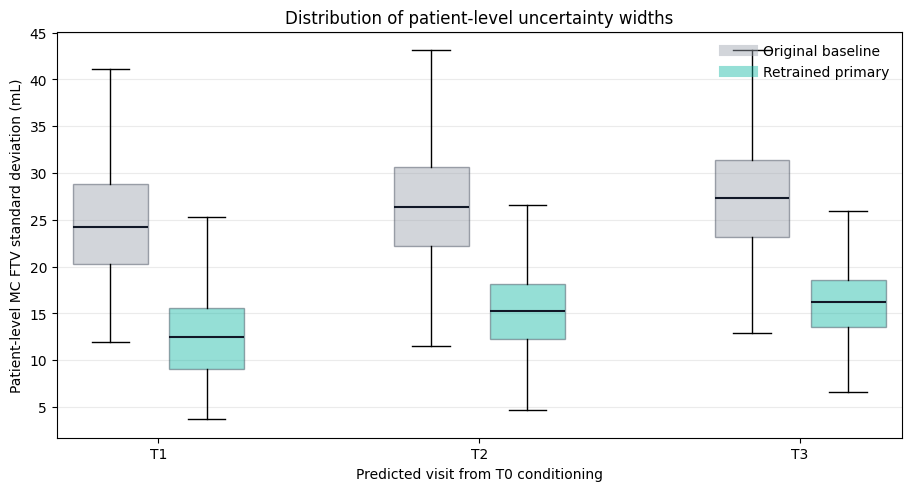

,model,predicted_visit,mean,median,q25,q75
0,Original baseline,T1,24.71,24.25,20.24,28.80
1,Original baseline,T2,26.79,26.40,22.21,30.65
2,Original baseline,T3,27.56,27.32,23.21,31.36
3,Retrained primary,T1,12.60,12.47,9.04,15.58
4,Retrained primary,T2,15.33,15.29,12.26,18.19
5,Retrained primary,T3,16.10,16.23,13.54,18.54


In [15]:
std_long = pd.concat([
    baseline_t0.assign(model="Original baseline"),
    primary_t0.assign(model="Retrained primary"),
], ignore_index=True)
std_long["predicted_visit"] = pd.Categorical(std_long["predicted_visit"], categories=FUTURE_VISITS, ordered=True)

positions = []
box_data = []
box_colors = []
labels = []
base_positions = np.arange(len(FUTURE_VISITS)) * 3.0
for i, visit in enumerate(FUTURE_VISITS):
    for offset, model, color in [(-0.45, "Original baseline", "#9ca3af"), (0.45, "Retrained primary", "#14b8a6")]:
        positions.append(base_positions[i] + offset)
        box_data.append(std_long[(std_long["predicted_visit"].eq(visit)) & (std_long["model"].eq(model))]["ftv_mc_std_ml"].to_numpy())
        box_colors.append(color)
        labels.append(model)

fig, ax = plt.subplots(figsize=(9, 4.8), constrained_layout=True)
box = ax.boxplot(box_data, positions=positions, widths=0.7, patch_artist=True, showfliers=False)
for patch, color in zip(box["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.45)
    patch.set_edgecolor("#374151")
for median in box["medians"]:
    median.set_color("#111827")
    median.set_linewidth(1.5)
ax.set_xticks(base_positions, FUTURE_VISITS)
ax.set_xlabel("Predicted visit from T0 conditioning")
ax.set_ylabel("Patient-level MC FTV standard deviation (mL)")
ax.grid(axis="y", alpha=0.25)
ax.set_title("Distribution of patient-level uncertainty widths")
legend_handles = [
    plt.Line2D([0], [0], color="#9ca3af", lw=8, alpha=0.45, label="Original baseline"),
    plt.Line2D([0], [0], color="#14b8a6", lw=8, alpha=0.45, label="Retrained primary"),
]
ax.legend(handles=legend_handles, frameon=False)
fig.savefig(FIG_DIR / "mc_t0_to_t3_std_distribution.png", dpi=220, bbox_inches="tight")
plt.show()

std_summary = std_long.groupby(["model", "predicted_visit"], observed=True)["ftv_mc_std_ml"].agg([
    "mean", "median", lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)
]).rename(columns={"<lambda_0>": "q25", "<lambda_1>": "q75"}).reset_index()
std_summary.style.format({"mean": "{:.2f}", "median": "{:.2f}", "q25": "{:.2f}", "q75": "{:.2f}"})

### What these visuals show

The retrained model does not just improve aggregate MAE. At the patient level, the MC mean trajectory is usually closer to the observed trajectory, and the uncertainty bands are much narrower. The cohort-wide sorted plot shows the same pattern across all T0-to-T3 patients: the baseline MC distribution is often very wide and shifted high after residual correction, while the retrained model is centered closer to observed T3 FTV with less spread.

The standard-deviation boxplot is the most direct answer to the mean/std question. It compares the distribution of patient-level MC FTV standard deviations for T1, T2, and T3 from the same T0 conditioning setup. The updated model has smaller uncertainty widths because the deterministic center is better calibrated, so the residual MC layer does not need to compensate with such broad sampled FTV distributions.

## Practical conclusion

The updated MC run supports the original diagnosis. The old uncertainty problem was not mainly a failure of conformal correction; it was a biased deterministic center. Once the deterministic center was FTV-calibrated, the unchanged MC sampler produced lower point error, better raw coverage, narrower conformal intervals, lower Continuous Ranked Probability Score, and much better alive-count calibration.

I would keep `bio_ftv020_alive005` as the primary candidate because it is the best balanced model: strong deterministic FTV calibration, strong MC calibration, and the best alive-count behavior among the top volume candidates. The FTV-only ablation is important because it shows that aggregate FTV supervision explains much of the volume calibration gain, but its weaker alive-count calibration makes it less attractive as the main rollout model.

The next methodological step is to decide whether the corrected random-start + horizon model should become the final architecture. If so, the same conditional MC run should be repeated on that checkpoint family. The comparison should be interpreted separately from this notebook: these completed MC results establish that FTV-calibrated retraining fixes the major MC calibration failure under the original scheduled-sampling bio grid.

In [16]:
# Save concise tables for manuscript/report reuse.
artifact_dir = DATA_DIR / "derived_notebook_tables"
artifact_dir.mkdir(exist_ok=True)
compact.to_csv(artifact_dir / "compact_model_comparison.csv", index=False)
paired_view.to_csv(artifact_dir / "paired_patient_delta_summary.csv", index=False)
mc_t3_view.to_csv(artifact_dir / "mc_t0t3_model_comparison.csv", index=False)
t3_compare.to_csv(artifact_dir / "mc_t3_conditioning_comparison.csv", index=False)
subgroup_view.to_csv(artifact_dir / "mc_primary_t0t3_subgroup_summary.csv", index=False)
pd.DataFrame(selection_notes, columns=["selection_reason", "patient_id"]).to_csv(artifact_dir / "mc_trajectory_example_patients.csv", index=False)
std_summary.to_csv(artifact_dir / "mc_t0_to_t3_std_summary.csv", index=False)
artifact_dir

PosixPath('/Users/irisseaman/Research/3DGCNN/reports/consistent_forecaster_v2_bio_eval/notebook_exports/derived_notebook_tables')